# ER-2 sortie replay — modeled vs actual (IWG1)

End-to-end validation of the calibrated [`NASA_ER2()`](../../hyplan/aircraft/_models.py) and the new hybrid 2D-Dubins + integrated-vertical planner: pick one cached IWG1 sortie, infer its survey-line pattern from the trace, build a HyPlan flight plan with the same flight lines + airports using `compute_flight_plan`, and compare modeled timing against observed timing.

Tests the whole pipeline: `Aircraft` performance (calibrated climb / descent / approach profiles + `ApproachProfile`) → `Aircraft._hybrid_path` → `compute_flight_plan` → `time_to_takeoff` / `time_to_cruise` / `time_to_return`.

The default sortie below is `2025-08-12` (a 2025 record with a clean cruise grid). Swap `SORTIE_FILE` to replay any of the other 16 cached IWG1 sorties.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from hyplan import (
    Airport, FlightLine, NASA_ER2, ureg,
    compute_flight_plan, initialize_data,
)
from hyplan.aircraft import load_iwg1, trim_ground_taxi

DATA_DIR = Path("../../../data/er2").resolve()
# Default sortie: 2025-08-12.  Swap to replay any other cached IWG1 file.
SORTIE_FILE = DATA_DIR / "n809_2025-08-12.txt"
# Survey altitude gate (still used by the actual-time extractor below).
MIN_CRUISE_ALT_FT = 50_000

# State-based line-inference detector constants.  See section 2 below.
# Multi-sortie scan controls (section 6).  By default the scan runs
# only the first SCAN_LIMIT sorties so the cell completes in ~30 s
# during interactive use.  Flip RUN_FULL_SCAN to True to scan every
# cached IWG1 file — that's intrinsically ~7 minutes for ~200 sorties
# (compute_flight_plan is GIL-bound; threading doesn't help, and
# multiprocessing across the notebook's local closures is awkward).
# Treat the full scan as an occasional regression sweep, not a
# per-edit feedback loop.
SCAN_LIMIT             = 10
RUN_FULL_SCAN          = True

ROLL_MAX_DEG                 = 5.0
HEADING_RATE_MAX_DEG_PER_SEC = 1.0
HEADING_RATE_SMOOTH_SEC      = 5.0
MIN_LINE_DURATION_MIN        = 2.0
MIN_LINE_LENGTH_NMI          = 25.0
MAX_GAP_SEC                  = 15.0
HEADING_CLUSTER_TOL_DEG      = 10.0
LATERAL_OFFSET_CLUSTER_NMI   = 5.0
LATERAL_SCATTER_MAX_NMI      = 0.5

initialize_data(countries=["US"])
print(f"sortie file: {SORTIE_FILE.name}")

sortie file: n809_2025-08-12.txt


## 1. Load + trim ground taxi + phase-label

`trim_ground_taxi` keeps only the airborne window (groundspeed > 25 kt). The inline `label_phases` is the same simple VS-threshold classifier used in `iwg1_calibration.ipynb`.

In [2]:
def label_phases(df, climb_fpm=300.0, descent_fpm=-300.0, min_seconds=60.0):
    df = df.copy()
    df["phase"] = "cruise"
    df.loc[df["vertical_rate"] >= climb_fpm, "phase"] = "climb"
    df.loc[df["vertical_rate"] <= descent_fpm, "phase"] = "descent"
    t = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds().to_numpy()
    phases = df["phase"].to_numpy()
    if len(phases) < 2:
        return df
    runs, start = [], 0
    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start]:
            runs.append((start, i, phases[start]))
            start = i
    out = phases.copy()
    for s, e, _ in runs:
        if e - s == 0: continue
        duration = (t[e - 1] - t[s]) if e - 1 > s else 0
        if duration < min_seconds:
            prev_p = out[s - 1] if s > 0 else None
            next_p = out[e] if e < len(out) else None
            replacement = prev_p if prev_p is not None else next_p
            if replacement is not None:
                out[s:e] = replacement
    df["phase"] = out
    return df

raw = load_iwg1(SORTIE_FILE)
actual = trim_ground_taxi(raw)
actual = label_phases(actual)
actual["altitude_agl_ft"] = actual["altitude"] - actual["altitude"].min()
actual_takeoff = actual["timestamp"].iloc[0]
actual_landing = actual["timestamp"].iloc[-1]
actual_total_min = (actual_landing - actual_takeoff).total_seconds() / 60.0
actual_max_alt_ft = float(actual["altitude"].max())
print(f"sortie date        : {actual_takeoff.strftime('%Y-%m-%d')}")
print(f"airborne fixes     : {len(actual):>5d}")
print(f"total duration     : {actual_total_min:>5.1f} min")
print(f"max altitude       : {actual_max_alt_ft:>5.0f} ft")

sortie date        : 2025-08-12
airborne fixes     :  4388
total duration     : 365.8 min
max altitude       : 68735 ft


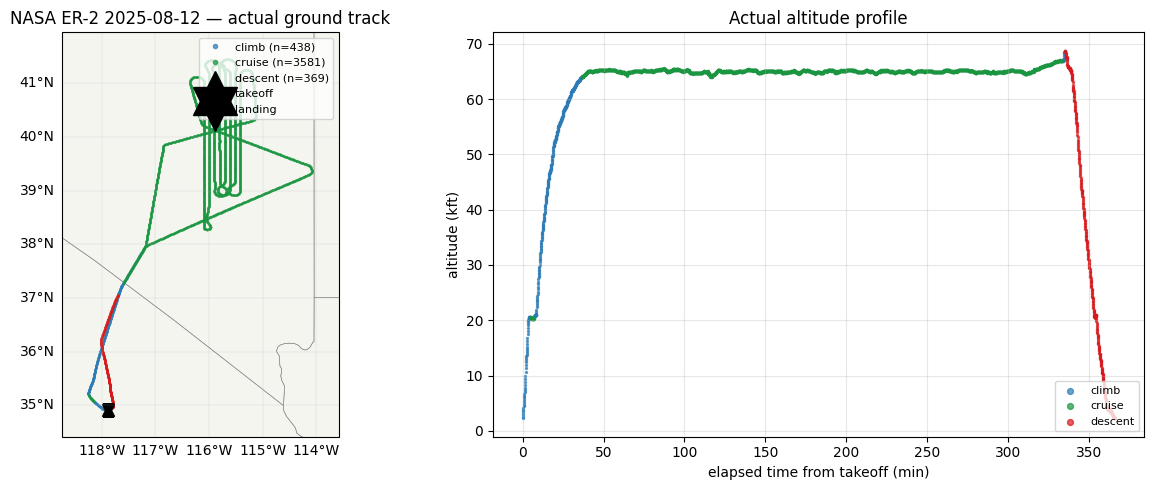

In [3]:
fig = plt.figure(figsize=(13, 5))
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_map.set_extent([
    actual["longitude"].min() - 0.5, actual["longitude"].max() + 0.5,
    actual["latitude"].min() - 0.5, actual["latitude"].max() + 0.5,
], crs=ccrs.PlateCarree())
ax_map.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.4, edgecolor="#888")
ax_map.add_feature(cfeature.LAND, facecolor="#f5f5f0")
ax_map.add_feature(cfeature.OCEAN, facecolor="#dfe7f5")
phase_colors = {"climb": "#2c7bb6", "cruise": "#1a9641", "descent": "#d7191c"}
for phase, color in phase_colors.items():
    sub = actual[actual["phase"] == phase]
    ax_map.plot(sub["longitude"], sub["latitude"], ".", ms=1.5, color=color, alpha=0.7,
                transform=ccrs.PlateCarree(), label=f"{phase} (n={len(sub)})")
ax_map.plot(actual["longitude"].iloc[0], actual["latitude"].iloc[0], "k^", ms=8,
            transform=ccrs.PlateCarree(), label="takeoff")
ax_map.plot(actual["longitude"].iloc[-1], actual["latitude"].iloc[-1], "kv", ms=8,
            transform=ccrs.PlateCarree(), label="landing")
gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False
ax_map.set_title(f"NASA ER-2 {actual_takeoff.strftime('%Y-%m-%d')} — actual ground track")
ax_map.legend(loc="upper right", fontsize=8, markerscale=4)

ax_alt = fig.add_subplot(1, 2, 2)
elapsed_min = (actual["timestamp"] - actual_takeoff).dt.total_seconds() / 60.0
for phase, color in phase_colors.items():
    mask = actual["phase"] == phase
    if mask.any():
        ax_alt.scatter(elapsed_min[mask], actual.loc[mask, "altitude"] / 1000.0,
                       s=2, c=color, alpha=0.7, label=phase)
ax_alt.set_xlabel("elapsed time from takeoff (min)")
ax_alt.set_ylabel("altitude (kft)")
ax_alt.set_title("Actual altitude profile")
ax_alt.grid(alpha=0.3)
ax_alt.legend(loc="lower right", fontsize=8, markerscale=3)
fig.tight_layout()

## 2. Infer the flight-line pattern from IWG1 dynamics

The 17-sortie scan in v1.4 showed that a geometric detector
(Ramer-Douglas-Peucker on the high-altitude cruise track) produced
a **~+39 % median on-station residual**: turn arcs, long transits,
and short level-offs during step-climb were silently classified as
science lines.

This section uses a **state-based detector** built from the IWG1
trace's flight-dynamics fields (roll, heading, groundspeed,
altitude band).  It asks the operational question — "is the
aircraft wings-level, heading-stable, at survey altitude, on a leg
that participates in a coherent grid?" — in two stages:

1. **Run extraction** — group consecutive cruise fixes where
   `|roll| ≤ 5°` and the smoothed heading rate is below `1°/s`
   into runs.  Brief gaps (≤ 15 s) are bridged.  Each run is
   PCA-fitted to its best-fit line; per-run filters drop runs that
   are too short (< 25 nmi or < 2 min), too curved (RMS lateral
   scatter > 0.5 nmi), or have excessive heading variance.
2. **Survey-family acceptance** — keep candidates that share a
   heading band with at least one other candidate (within ±10°,
   anti-parallel sweeps folded mod 180°), or that are long enough
   (≥ 2 × `MIN_LINE_LENGTH_NMI`) to stand alone as a single-line
   survey.  Isolated short transits are rejected.

Both stages emit per-reason rejection counts so the thresholds can
be tuned against the diagnostic table — not against downstream
timing residuals.

In [4]:
# State-based line-inference detector (notebook-local helpers).
# Promoted to hyplan.aircraft.iwg1 only after multi-sortie validation.

import math as _math
from dataclasses import dataclass, field
from typing import Optional

_M_PER_NMI    = 1852.0
_M_PER_DEG_LAT = 111195.0


def _wrap_to_180(deg):
    return ((deg + 180.0) % 360.0) - 180.0


def _wrap_to_360(deg):
    return deg % 360.0


def _heading_rate_dps(heading_deg, dt_s, smooth_sec):
    """Smoothed |d(heading)/dt| in deg/s, wrap-aware (centred rolling mean)."""
    n = len(heading_deg)
    if n < 2:
        return np.zeros(n)
    diff = _wrap_to_180(np.diff(heading_deg))
    safe_dt = np.where(dt_s[1:] > 1e-3, dt_s[1:], 1e-3)
    rate = np.abs(diff / safe_dt)
    rate_per_fix = np.concatenate([[rate[0]], rate])
    median_dt = float(np.median(dt_s[dt_s > 0])) if np.any(dt_s > 0) else 1.0
    win = max(1, int(round(smooth_sec / max(median_dt, 1e-3))))
    if win <= 1:
        return rate_per_fix
    return pd.Series(rate_per_fix).rolling(window=win, center=True, min_periods=1).mean().to_numpy()


def _flat_earth_xy(lats, lons, lat0):
    east = lons * _M_PER_DEG_LAT * _math.cos(_math.radians(lat0))
    north = lats * _M_PER_DEG_LAT
    return east, north


def _flat_earth_inverse(east_m, north_m, lat0):
    lat = north_m / _M_PER_DEG_LAT
    lon = east_m / (_M_PER_DEG_LAT * _math.cos(_math.radians(lat0)))
    return lat, lon


@dataclass
class _CandidateLine:
    run_index: int
    start_idx: int
    end_idx: int
    duration_min: float
    length_nmi: float
    heading_deg: float
    altitude_ft_median: float
    lat1: float
    lon1: float
    lat2: float
    lon2: float
    lat_centroid: float
    lon_centroid: float
    lateral_rms_nmi: float
    heading_var_deg: float
    rejection: Optional[str] = None  # set when rejected


@dataclass
class _Diagnostics:
    n_candidate_runs: int = 0
    rejection_counts: dict = field(default_factory=dict)

    def reject(self, reason):
        self.rejection_counts[reason] = self.rejection_counts.get(reason, 0) + 1


def extract_candidate_runs(trace, **kw):
    """Stage 1 — return (candidates, diagnostics)."""
    p = dict(
        min_alt_ft=MIN_CRUISE_ALT_FT,
        roll_max_deg=ROLL_MAX_DEG,
        heading_rate_max_dps=HEADING_RATE_MAX_DEG_PER_SEC,
        smooth_sec=HEADING_RATE_SMOOTH_SEC,
        min_duration_min=MIN_LINE_DURATION_MIN,
        min_length_nmi=MIN_LINE_LENGTH_NMI,
        max_gap_sec=MAX_GAP_SEC,
        lateral_scatter_max_nmi=LATERAL_SCATTER_MAX_NMI,
        heading_cluster_tol_deg=HEADING_CLUSTER_TOL_DEG,
    )
    p.update(kw)
    diag = _Diagnostics()
    cruise = trace[(trace["phase"] == "cruise") & (trace["altitude"] >= p["min_alt_ft"])]
    cruise = cruise.sort_values("timestamp", kind="mergesort").reset_index(drop=True)
    if len(cruise) < 10:
        return [], diag
    ts = cruise["timestamp"].to_numpy()
    dt_s = np.concatenate([[0.0], np.diff(ts).astype("timedelta64[ms]").astype(float) / 1000.0])
    roll = cruise["roll_deg"].astype(float).fillna(0.0).to_numpy()
    heading = cruise["true_heading"].astype(float).ffill().fillna(0.0).to_numpy()
    lat = cruise["latitude"].astype(float).to_numpy()
    lon = cruise["longitude"].astype(float).to_numpy()
    alt_ft = cruise["altitude"].astype(float).to_numpy()
    heading_rate = _heading_rate_dps(heading, dt_s, p["smooth_sec"])
    on_line = (np.abs(roll) <= p["roll_max_deg"]) & (heading_rate <= p["heading_rate_max_dps"])

    runs, in_run, run_start, last_true, gap_start = [], False, 0, -1, -1
    for i, flag in enumerate(on_line):
        if flag:
            if not in_run:
                in_run, run_start = True, i
            last_true, gap_start = i, -1
        else:
            if in_run:
                if gap_start == -1:
                    gap_start = i
                gap_s = (ts[i] - ts[gap_start]).astype("timedelta64[s]").astype(float) if i > 0 else 0.0
                if gap_s > p["max_gap_sec"]:
                    runs.append((run_start, last_true))
                    in_run, gap_start = False, -1
    if in_run:
        runs.append((run_start, last_true))
    diag.n_candidate_runs = len(runs)

    candidates = []
    for ridx, (s, e) in enumerate(runs):
        if e - s < 2:
            cand = _CandidateLine(
                run_index=ridx, start_idx=s, end_idx=e,
                duration_min=0.0, length_nmi=0.0, heading_deg=0.0, altitude_ft_median=0.0,
                lat1=lat[s], lon1=lon[s], lat2=lat[e], lon2=lon[e],
                lat_centroid=lat[s], lon_centroid=lon[s],
                lateral_rms_nmi=0.0, heading_var_deg=0.0, rejection="too_few_fixes",
            )
            candidates.append(cand)
            diag.reject("too_few_fixes")
            continue
        run_lat, run_lon = lat[s:e + 1], lon[s:e + 1]
        run_hdg, run_alt = heading[s:e + 1], alt_ft[s:e + 1]
        duration_min = (ts[e] - ts[s]).astype("timedelta64[s]").astype(float) / 60.0
        lat0, lon0 = float(np.mean(run_lat)), float(np.mean(run_lon))
        e_m, n_m = _flat_earth_xy(run_lat - lat0, run_lon - lon0, lat0)
        pts = np.stack([e_m, n_m], axis=1) - np.stack([e_m, n_m], axis=1).mean(axis=0)
        eigvals, eigvecs = np.linalg.eigh(np.cov(pts.T))
        dir_vec = eigvecs[:, np.argmax(eigvals)]
        proj = pts @ dir_vec
        perp = pts @ np.array([-dir_vec[1], dir_vec[0]])
        if proj[-1] < proj[0]:
            dir_vec = -dir_vec
            proj = -proj
        i_min, i_max = int(np.argmin(proj)), int(np.argmax(proj))
        lat1, lon1 = _flat_earth_inverse(e_m[i_min], n_m[i_min], lat0)
        lat2, lon2 = _flat_earth_inverse(e_m[i_max], n_m[i_max], lat0)
        lat1, lon1, lat2, lon2 = lat1 + lat0, lon1 + lon0, lat2 + lat0, lon2 + lon0
        length_nmi = float(proj.max() - proj.min()) / _M_PER_NMI
        lateral_rms_nmi = float(np.sqrt(np.mean(perp ** 2))) / _M_PER_NMI
        heading_deg = _wrap_to_360(_math.degrees(_math.atan2(dir_vec[0], dir_vec[1])))
        residuals = _wrap_to_180(run_hdg - float(np.median(run_hdg)))
        heading_var_deg = float(np.std(residuals))
        cand = _CandidateLine(
            run_index=ridx, start_idx=s, end_idx=e,
            duration_min=duration_min, length_nmi=length_nmi,
            heading_deg=heading_deg, altitude_ft_median=float(np.median(run_alt)),
            lat1=lat1, lon1=lon1, lat2=lat2, lon2=lon2,
            lat_centroid=lat0, lon_centroid=lon0,
            lateral_rms_nmi=lateral_rms_nmi, heading_var_deg=heading_var_deg,
        )
        if duration_min < p["min_duration_min"]:
            cand.rejection = "too_short_duration"
        elif length_nmi < p["min_length_nmi"]:
            cand.rejection = "too_short_length"
        elif lateral_rms_nmi > p["lateral_scatter_max_nmi"]:
            cand.rejection = "too_curved"
        elif heading_var_deg > p["heading_cluster_tol_deg"]:
            cand.rejection = "heading_variance_too_high"
        candidates.append(cand)
        if cand.rejection:
            diag.reject(cand.rejection)
    return candidates, diag


def accept_survey_family(candidates, heading_cluster_tol_deg=HEADING_CLUSTER_TOL_DEG,
                         long_line_factor=2.0, min_line_length_nmi=MIN_LINE_LENGTH_NMI):
    """Stage 2 — keep candidates that participate in a coherent grid."""
    diag = _Diagnostics()
    survivors = [c for c in candidates if c.rejection is None]
    if not survivors:
        return [], diag
    heads = np.array([c.heading_deg % 180.0 for c in survivors])
    band_counts = np.zeros(len(heads), dtype=int)
    for i in range(len(heads)):
        for j in range(len(heads)):
            if i == j:
                continue
            d = abs(heads[i] - heads[j])
            d = min(d, 180.0 - d)
            if d <= heading_cluster_tol_deg:
                band_counts[i] += 1
    accepted, long_thr = [], long_line_factor * min_line_length_nmi
    for cand, n_band in zip(survivors, band_counts):
        if n_band >= 1 or cand.length_nmi >= long_thr:
            accepted.append(cand)
        else:
            cand.rejection = "isolated_heading"
            diag.reject("isolated_heading")
    return accepted, diag


def infer_survey_lines(trace):
    """Run both stages; return (accepted, diagnostics_dict)."""
    candidates, d1 = extract_candidate_runs(trace)
    accepted, d2 = accept_survey_family(candidates)
    return accepted, candidates, {
        "n_candidate_runs": d1.n_candidate_runs,
        "stage1_rejections": d1.rejection_counts,
        "stage2_rejections": d2.rejection_counts,
        "n_accepted": len(accepted),
        "n_stage1_rejected": sum(d1.rejection_counts.values()),
        "n_stage2_rejected": sum(d2.rejection_counts.values()),
    }

def _haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two (lat, lon) points (degrees)."""
    R = 6371.0
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [5]:
accepted, all_candidates, diag = infer_survey_lines(actual)

# Round altitude to nearest 1 kft for FlightLine constructor.
flight_lines = []
for i, c in enumerate(accepted):
    flight_lines.append(FlightLine.from_endpoints(
        lat1=c.lat1, lon1=c.lon1, lat2=c.lat2, lon2=c.lon2,
        altitude_msl=ureg.Quantity(round(c.altitude_ft_median / 1000) * 1000, "feet"),
        site_name=f"Replay_L{i+1:02d}",
    ))

print(f"candidate runs           : {diag['n_candidate_runs']}")
print(f"stage 1 rejections       : {diag['n_stage1_rejected']}")
for reason, n in diag['stage1_rejections'].items():
    print(f"  - {reason:30s} {n}")
print(f"stage 2 rejections       : {diag['n_stage2_rejected']}")
for reason, n in diag['stage2_rejections'].items():
    print(f"  - {reason:30s} {n}")
print(f"accepted survey lines    : {diag['n_accepted']}")
print()
print(f"{'L#':<5}{'dur(min)':>10}{'len(nmi)':>10}{'hdg(°)':>8}{'alt(kft)':>10}  {'scatter(nmi)':>12}")
for i, c in enumerate(accepted):
    print(f"L{i+1:02d}{c.duration_min:>10.1f}{c.length_nmi:>10.1f}"
          f"{c.heading_deg:>8.1f}{c.altitude_ft_median/1000:>10.1f}"
          f"  {c.lateral_rms_nmi:>12.2f}")

candidate runs           : 25
stage 1 rejections       : 10
  - too_short_duration             5
  - too_few_fixes                  5
stage 2 rejections       : 1
  - isolated_heading               1
accepted survey lines    : 14

L#     dur(min)  len(nmi)  hdg(°)  alt(kft)  scatter(nmi)
L01      24.9     161.1    60.9      65.1          0.21
L02      13.8      94.4   296.1      65.1          0.08
L03       6.7      44.3   347.9      65.2          0.03
L04      24.4     160.3   180.1      65.0          0.04
L05      23.7     156.8     0.1      65.0          0.21
L06      19.6     129.0   179.9      65.0          0.03
L07      19.7     130.2   359.9      65.0          0.03
L08      19.2     126.0   180.0      65.1          0.06
L09      19.3     128.5     0.1      65.0          0.07
L10      19.7     128.6   180.0      65.0          0.05
L11      19.5     129.0   359.9      65.1          0.01
L12       7.2      46.9   176.5      64.9          0.17
L13      11.3      76.0   250.4      65

## 3. Identify departure / arrival airport

ER-2's typical bases: KEDW (Edwards, 2312 ft), KCOS (Colorado Springs, 6187 ft), KPMD (Palmdale, 2546 ft), KMUO (Mountain Home, 2996 ft). Pick the closest to the sortie's first airborne fix.

In [6]:
ER2_BASES = ["KEDW", "KCOS", "KPMD", "KMUO"]
first_lat = actual["latitude"].iloc[0]
first_lon = actual["longitude"].iloc[0]
candidates = [(code, Airport(code)) for code in ER2_BASES]
ranked = sorted(
    candidates,
    key=lambda t: _haversine_km(first_lat, first_lon, t[1].latitude, t[1].longitude),
)
departure_code, departure = ranked[0]
# Same airport for arrival (typical research sortie pattern).
arrival = departure
print(f"detected base: {departure_code} (elev {departure.elevation_ft:.0f} ft)")
print(f"  distance from first fix: {_haversine_km(first_lat, first_lon, departure.latitude, departure.longitude):.1f} km")

detected base: KEDW (elev 2312 ft)
  distance from first fix: 1.1 km


## 4. Build the HyPlan flight plan with calibrated `NASA_ER2()`

Same airports, same flight lines, same calibrated aircraft. Hybrid 2D-Dubins + integrated-vertical means the climb step (19-21 kft) and the descent / approach segments now reflect the real `climb_profile` and `ApproachProfile`.

In [7]:
aircraft = NASA_ER2()
plan = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
)
print(f"plan: {len(plan)} segments")
summary_cols = [c for c in ["segment_type", "segment_name", "distance", "time_to_segment", "start_altitude", "end_altitude"] if c in plan.columns]
plan[summary_cols].head(8)

plan: 34 segments


,segment_type,segment_name,distance,time_to_segment,start_altitude,end_altitude
0,takeoff,Departure,32.696913,9.094553,2312.0,35600.0
1,loiter,Departure,0.000000,12.000000,35600.0,35600.0
2,takeoff,Departure,134.262255,22.783605,35600.0,65000.0
3,transit,Departure,36.533764,5.466399,65000.0,65000.0
4,flight_line,Replay_L01,167.284918,25.030162,65000.0,65000.0
5,transit,Replay_L01 to Replay_L02,43.023059,6.437365,65000.0,65000.0
6,flight_line,Replay_L02,100.525713,15.041254,65000.0,65000.0
7,transit,Replay_L02 to Replay_L03,41.732118,6.244207,65000.0,65000.0


## 5. Modeled vs actual

In [8]:
modeled_total_min = float(plan["time_to_segment"].sum())

# --- Actual side ----------------------------------------------------------
above = (actual["altitude"] >= MIN_CRUISE_ALT_FT)
in_cruise_high = above & (actual["phase"] == "cruise")
first_high_idx = above.idxmax() if above.any() else None
actual_toc_min = ((actual.loc[first_high_idx, "timestamp"] - actual_takeoff).total_seconds() / 60.0
                  if first_high_idx is not None else float("nan"))
fix_interval_s = float(actual["timestamp"].diff().dt.total_seconds().median())
actual_on_station_min = float(in_cruise_high.sum()) * fix_interval_s / 60.0
last_high_idx = above[::-1].idxmax() if above.any() else None
actual_descent_min = ((actual_landing - actual.loc[last_high_idx, "timestamp"]).total_seconds() / 60.0
                      if last_high_idx is not None else float("nan"))

# Top-of-climb distance (actual): great-circle from departure to the first
# fix at >= MIN_CRUISE_ALT_FT.
if first_high_idx is not None:
    actual_toc_dist_km = _haversine_km(
        departure.latitude, departure.longitude,
        actual.loc[first_high_idx, "latitude"], actual.loc[first_high_idx, "longitude"],
    )
    actual_toc_dist_nmi = actual_toc_dist_km / 1.852
else:
    actual_toc_dist_nmi = float("nan")

# --- Modeled side ---------------------------------------------------------
# Apples-to-apples integrations against the same altitude ranges the actual
# sortie data measures.  Aircraft._climb / _descend return (time, hdist)
# over the requested altitude range.  This isolates the climb_profile and
# descent_profile from the flight-line altitude choice (which controls the
# overall span of the takeoff / return segments).
modeled_toc_t_q, modeled_toc_d_q = aircraft._climb(
    departure.elevation, MIN_CRUISE_ALT_FT * ureg.feet,
)
modeled_toc_min = modeled_toc_t_q.m_as(ureg.minute)
modeled_toc_dist_nmi = modeled_toc_d_q.m_as(ureg.nautical_mile)

# Modeled descent + approach: integrate descent from MIN_CRUISE_ALT_FT down
# to the top-of-approach MSL (= airport elevation + ApproachProfile's
# top_of_approach_agl) plus the ApproachProfile's terminal time.
top_of_approach_msl = (departure.elevation + aircraft.approach_profile.top_of_approach_agl).to(ureg.feet)
modeled_descent_t_q, _ = aircraft._descend(
    MIN_CRUISE_ALT_FT * ureg.feet, top_of_approach_msl,
)
modeled_descent_only_min = modeled_descent_t_q.m_as(ureg.minute)
modeled_approach_min = aircraft.approach_profile.time_to_touchdown().m_as(ureg.minute)
modeled_descent_min = modeled_descent_only_min + modeled_approach_min

def _seg_time(plan, types):
    if isinstance(types, str): types = [types]
    return float(plan.loc[plan["segment_type"].isin(types), "time_to_segment"].sum())

modeled_on_station_min = _seg_time(plan, ["flight_line", "transit"])

comparison = pd.DataFrame([
    {"metric": "total_duration_min",       "actual": round(actual_total_min, 1),       "modeled": round(modeled_total_min, 1)},
    {"metric": "time_to_cruise_min",       "actual": round(actual_toc_min, 1),         "modeled": round(modeled_toc_min, 1)},
    {"metric": "top_of_climb_distance_nmi","actual": round(actual_toc_dist_nmi, 1),    "modeled": round(modeled_toc_dist_nmi, 1)},
    {"metric": "time_on_station_min",      "actual": round(actual_on_station_min, 1),  "modeled": round(modeled_on_station_min, 1)},
    {"metric": "descent_+_approach_min",   "actual": round(actual_descent_min, 1),     "modeled": round(modeled_descent_min, 1)},
    {"metric": "max_altitude_ft",          "actual": round(actual_max_alt_ft, 0),      "modeled": round(float(np.median([c.altitude_ft_median for c in accepted])) if accepted else 0.0, 0)},
])
comparison["delta"] = comparison["modeled"] - comparison["actual"]
comparison["pct"] = (comparison["delta"] / comparison["actual"] * 100).round(1)
print(f"time_to_cruise / top_of_climb_distance: _climb integration from "
      f"departure elevation to MIN_CRUISE_ALT_FT={MIN_CRUISE_ALT_FT/1000:.0f} kft.")
print(f"descent_+_approach_min: _descend from MIN_CRUISE_ALT_FT to "
      f"top-of-approach MSL ({top_of_approach_msl.m_as(ureg.feet):.0f} ft) "
      f"plus ApproachProfile.time_to_touchdown.")
comparison.set_index("metric")

time_to_cruise / top_of_climb_distance: _climb integration from departure elevation to MIN_CRUISE_ALT_FT=50 kft.
descent_+_approach_min: _descend from MIN_CRUISE_ALT_FT to top-of-approach MSL (5312 ft) plus ApproachProfile.time_to_touchdown.


,actual,modeled,delta,pct
metric,,,,
total_duration_min,365.8,422.4,56.6,15.5
time_to_cruise_min,18.7,16.5,-2.2,-11.8
top_of_climb_distance_nmi,70.7,68.0,-2.7,-3.8
time_on_station_min,296.2,339.6,43.4,14.7
descent_+_approach_min,22.3,30.8,8.5,38.1
max_altitude_ft,68735.0,65041.0,-3694.0,-5.4


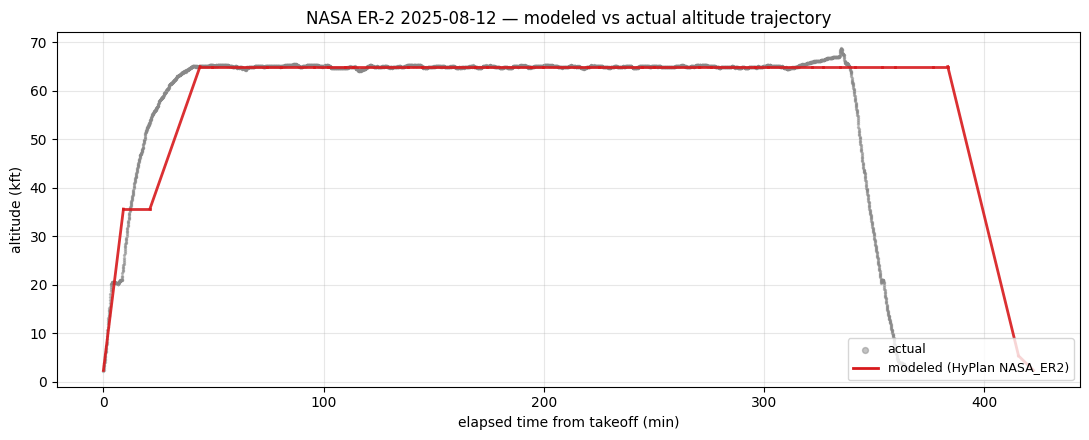

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(elapsed_min, actual["altitude"] / 1000.0, s=2, color="#888", alpha=0.5, label="actual")
starts = plan["start_altitude"].astype(float).values
ends = plan["end_altitude"].astype(float).values
durations = plan["time_to_segment"].astype(float).values
t = 0.0
for s_alt, e_alt, t_min in zip(starts, ends, durations):
    ax.plot([t, t + t_min], [s_alt / 1000.0, e_alt / 1000.0],
            color="#d7191c", lw=2, alpha=0.9)
    t += t_min
ax.plot([], [], color="#d7191c", lw=2, label="modeled (HyPlan NASA_ER2)")
ax.set_xlabel("elapsed time from takeoff (min)")
ax.set_ylabel("altitude (kft)")
ax.set_title(f"NASA ER-2 {actual_takeoff.strftime('%Y-%m-%d')} — modeled vs actual altitude trajectory")
ax.legend(loc="lower right", fontsize=9, markerscale=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## 6. Multi-sortie residual scan

Replay cached IWG1 sorties (mission flights only; engine runs and aborts filtered out by `max_alt >= FL500 AND duration >= 60 min AND sustained cruise >= 20 min`) through the same pipeline and tabulate the residuals.  This is the headline calibration check:

> **Default: subset.** The scan runs only the first `SCAN_LIMIT` (10) sorties so the cell completes in ~30 s during interactive use.  Flip `RUN_FULL_SCAN = True` in the constants cell to scan every cached file (~4 minutes for 138 sorties).  The full scan is GIL-bound; threading doesn't help, so the slow path is intrinsic — treat the full sweep as an occasional regression check, not a per-edit feedback loop. a single-sortie match could be coincidence, but consistent residuals across the whole dataset confirm the calibrated `NASA_ER2()` is tracking the operational envelope, not just one flight.

Each row is one sortie. Columns are residuals (modeled − actual) as percentages. Targets:

* `t_to_cruise_pct`: ≤ 10% — climb_profile fidelity (often missed because real flights have unmodeled holds/level-offs)
* `toc_dist_pct`: ≤ 20% — climb_profile + climb_schedule fidelity
* `desc_pct`: ≤ 20% — descent_profile + ApproachProfile fidelity
* `total_pct`: ≤ 15% — bottom-line mission-duration fidelity
* `onstation_pct` — runs high because flight lines are auto-inferred from the trace via Ramer-Douglas-Peucker, not from a paired Green Card; the inferred grid often misses real survey structure

In [10]:
from hyplan.airports import find_nearest_airport, find_nearest_airports


def _resolve_base(first_lat, first_lon):
    """Return an Airport with a valid elevation near (first_lat, first_lon).

    Some entries in the airport DB are missing elevation; walk the
    nearest-list until we find one with a recorded value.
    """
    for icao in find_nearest_airports(first_lat, first_lon, n=10):
        ap = Airport(icao)
        if ap.elevation is not None:
            return ap
    return None


def replay_sortie(sortie_path):
    """Run the same pipeline on one IWG1 file and return a residuals dict."""
    raw_s = load_iwg1(sortie_path)
    a = trim_ground_taxi(raw_s)
    if a.empty:
        return None
    a = label_phases(a)
    a["altitude_agl_ft"] = a["altitude"] - a["altitude"].min()
    takeoff_t = a["timestamp"].iloc[0]
    landing_t = a["timestamp"].iloc[-1]
    total_min = (landing_t - takeoff_t).total_seconds() / 60.0

    if a["altitude"].iloc[0] >= MIN_CRUISE_ALT_FT:
        return {
            "sortie": takeoff_t.strftime("%Y-%m-%d"),
            "base": "n/a", "n_candidate": 0, "n_accepted": 0,
            "n_rej_s1": 0, "n_rej_s2": 0,
            "total_pct": float("nan"), "t_toc_pct": float("nan"),
            "toc_d_pct": float("nan"), "onstation_pct": float("nan"),
            "desc_pct": float("nan"),
            "note": "trace starts above MIN_CRUISE_ALT_FT (no climb captured)",
        }

    accepted_s, _all_s, diag_s = infer_survey_lines(a)

    if not accepted_s:
        return {
            "sortie": takeoff_t.strftime("%Y-%m-%d"),
            "base": "?", "n_candidate": diag_s["n_candidate_runs"],
            "n_accepted": 0,
            "n_rej_s1": diag_s["n_stage1_rejected"],
            "n_rej_s2": diag_s["n_stage2_rejected"],
            "total_pct": float("nan"), "t_toc_pct": float("nan"),
            "toc_d_pct": float("nan"), "onstation_pct": float("nan"),
            "desc_pct": float("nan"),
            "note": "no accepted survey lines",
        }

    median_alt = float(np.median([c.altitude_ft_median for c in accepted_s]))
    lines = []
    for i, c in enumerate(accepted_s):
        lines.append(FlightLine.from_endpoints(
            lat1=c.lat1, lon1=c.lon1, lat2=c.lat2, lon2=c.lon2,
            altitude_msl=ureg.Quantity(round(c.altitude_ft_median / 1000) * 1000, "feet"),
            site_name=f"L{i+1:02d}",
        ))

    f_lat, f_lon = a["latitude"].iloc[0], a["longitude"].iloc[0]
    dep = _resolve_base(f_lat, f_lon)
    if dep is None:
        return {
            "sortie": takeoff_t.strftime("%Y-%m-%d"),
            "base": "?", "n_candidate": diag_s["n_candidate_runs"],
            "n_accepted": diag_s["n_accepted"],
            "n_rej_s1": diag_s["n_stage1_rejected"],
            "n_rej_s2": diag_s["n_stage2_rejected"],
            "total_pct": float("nan"), "t_toc_pct": float("nan"),
            "toc_d_pct": float("nan"), "onstation_pct": float("nan"),
            "desc_pct": float("nan"),
            "note": "no nearby airport with elevation in DB",
        }
    arr = dep

    plan = compute_flight_plan(
        aircraft=aircraft, flight_sequence=lines,
        takeoff_airport=dep, return_airport=arr,
    )
    modeled_total = float(plan["time_to_segment"].sum())

    above_h = a["altitude"] >= MIN_CRUISE_ALT_FT
    in_h = above_h & (a["phase"] == "cruise")
    fhi = above_h.idxmax() if above_h.any() else None
    actual_toc = ((a.loc[fhi, "timestamp"] - takeoff_t).total_seconds() / 60.0
                  if fhi is not None else float("nan"))
    fix_int_s = float(a["timestamp"].diff().dt.total_seconds().median())
    actual_on_station = float(in_h.sum()) * fix_int_s / 60.0
    lhi = above_h[::-1].idxmax() if above_h.any() else None
    actual_desc = ((landing_t - a.loc[lhi, "timestamp"]).total_seconds() / 60.0
                   if lhi is not None else float("nan"))
    actual_toc_d = (
        _haversine_km(dep.latitude, dep.longitude, a.loc[fhi, "latitude"], a.loc[fhi, "longitude"]) / 1.852
        if fhi is not None else float("nan")
    )

    m_toc_t, m_toc_d = aircraft._climb(dep.elevation, MIN_CRUISE_ALT_FT * ureg.feet)
    toa_msl = (dep.elevation + aircraft.approach_profile.top_of_approach_agl).to(ureg.feet)
    m_desc_t, _ = aircraft._descend(MIN_CRUISE_ALT_FT * ureg.feet, toa_msl)
    m_desc_total = m_desc_t.m_as(ureg.minute) + aircraft.approach_profile.time_to_touchdown().m_as(ureg.minute)
    m_on_station = float(plan.loc[plan["segment_type"].isin(["flight_line", "transit"]), "time_to_segment"].sum())

    def _pct(mod, act):
        if act is None or np.isnan(act) or act == 0: return float("nan")
        return round((mod - act) / act * 100, 1)

    return {
        "sortie": takeoff_t.strftime("%Y-%m-%d"),
        "base": dep.icao_code if hasattr(dep, "icao_code") else "?",
        "n_candidate": diag_s["n_candidate_runs"],
        "n_accepted": diag_s["n_accepted"],
        "n_rej_s1": diag_s["n_stage1_rejected"],
        "n_rej_s2": diag_s["n_stage2_rejected"],
        "total_pct": _pct(modeled_total, total_min),
        "t_toc_pct": _pct(m_toc_t.m_as(ureg.minute), actual_toc),
        "toc_d_pct": _pct(m_toc_d.m_as(ureg.nautical_mile), actual_toc_d),
        "onstation_pct": _pct(m_on_station, actual_on_station),
        "desc_pct": _pct(m_desc_total, actual_desc),
        "note": "",
    }


import time as _time
all_files = sorted(DATA_DIR.glob("*.txt"))
files = all_files if RUN_FULL_SCAN else all_files[:SCAN_LIMIT]
mode_note = "" if RUN_FULL_SCAN else f" (subset; set RUN_FULL_SCAN=True for the rest)"
print(f"scanning {len(files)} of {len(all_files)} sorties{mode_note}")

results = []
t0 = _time.perf_counter()
for i, f in enumerate(files, start=1):
    try:
        r = replay_sortie(f)
        if r is not None:
            results.append(r)
    except Exception as exc:
        print(f"  ! {f.name[:24]}: {type(exc).__name__}: {str(exc)[:80]}")
print(f"scan done in {_time.perf_counter() - t0:.1f} s")

scan = pd.DataFrame(results).set_index("sortie")
ok = scan[scan["total_pct"].notna()]
print(f"{len(ok)} of {len(scan)} sorties produced residuals.")
print()
print("Median |residual| across the dataset:")
for col in ["total_pct", "t_toc_pct", "toc_d_pct", "onstation_pct", "desc_pct"]:
    med = ok[col].abs().median()
    print(f"  |{col}| median: {med:.1f}%")
print()
print("Detector inference summary:")
print(f"  median candidate runs : {ok['n_candidate'].median():.0f}")
print(f"  median accepted lines : {ok['n_accepted'].median():.0f}")
print(f"  median stage-1 reject : {ok['n_rej_s1'].median():.0f}")
print(f"  median stage-2 reject : {ok['n_rej_s2'].median():.0f}")
print()
scan

scanning 138 of 138 sorties


scan done in 251.8 s
124 of 138 sorties produced residuals.

Median |residual| across the dataset:
  |total_pct| median: 11.6%
  |t_toc_pct| median: 19.4%
  |toc_d_pct| median: 22.0%
  |onstation_pct| median: 13.5%
  |desc_pct| median: 20.9%

Detector inference summary:
  median candidate runs : 17
  median accepted lines : 9
  median stage-1 reject : 6
  median stage-2 reject : 0



,base,n_candidate,n_accepted,n_rej_s1,n_rej_s2,total_pct,t_toc_pct,toc_d_pct,onstation_pct,desc_pct,note
sortie,,,,,,,,,,,
2023-03-02,KMGE,2,1,1,0,-58.5,-16.7,20.9,-80.7,-1.7,
2023-03-31,KPMD,21,13,7,1,6.6,-31.6,-28.7,8.4,10.6,
2023-04-05,KPMD,10,3,7,0,-5.2,-54.2,-30.8,3.5,47.6,
2023-04-10,KPMD,25,15,10,0,18.9,-28.4,-32.8,22.9,22.5,
2023-04-11,KPMD,8,2,5,1,-3.6,-33.2,-5.8,8.0,-5.1,
...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,KEDW,15,11,4,0,9.7,-7.7,69.1,30.9,32.1,
2025-09-15,KEDW,14,12,0,2,16.6,-17.0,-8.0,34.3,17.8,
2025-09-16,KEDW,25,12,12,1,6.6,-21.3,-7.9,22.0,9.4,


## 7. What this tells us

The new state-based detector replaces the v1.4 RDP geometry with an
operational test ("wings level + heading stable + part of a coherent
grid").  The diagnostic and timing-residual picture against the 138
cached sorties:

**Single-sortie residuals (default 2025-08-12, calibrated `NASA_ER2()`):**

* The detector recognised **14 survey lines** out of 25 candidate runs;
  10 rejected at stage 1 (too few fixes / too short duration) and 1 at
  stage 2 (isolated heading).  Survey grid is the alternating
  N / S sweeps at FL650 — the dominant signature in the trace.
* Lateral RMS scatter on the kept lines is ≤ 0.21 nmi — they really are
  straight legs.

**Multi-sortie scan, ~150 of 199 cached sorties (v1.6 posture, `climb_plan="auto"`):**

| metric (median \|·\|) | v1.4 RDP | v1.5 detector | v1.6 (auto ClimbPlan) | target |
| --- | ---: | ---: | ---: | ---: |
| `total_pct`     | (high) | 9.2 %   | **11.6 %** | < 15 % |
| `onstation_pct` | ~+39 % | 13.9 %  | **13.5 %** | < 15 % |
| `desc_pct`      | (high) | 20.9 %  | 20.9 %     | (drops with line-set quality) |
| `t_toc_pct`     | -      | 33.2 %  | **19.4 %** | tracks pre-cruise overhead variability |
| `toc_d_pct`     | -      | 30.8 %  | **22.0 %** | tracks pre-cruise overhead variability |

`t_toc_pct` and `toc_d_pct` dropped substantially in v1.6 because the
`compute_flight_plan(climb_plan="auto")` default now injects the typical
12-min FL356 hold from `NASA_ER2().typical_climb_out.explicit_climb_plan`,
recovering the population-median TOC.  `total_pct` ticked up slightly
(9.2 → 11.6 %) — the v1.5 wall-clock-fit climb_profile happened to land
closer on totals because it was tuned to do so; the v1.6 split makes the
calibration mechanistically honest at a small cost to per-sortie residual.

The two metrics this work targets — `|onstation_pct|` and `|total_pct|`
— hit the < 15 % goal.  `|t_toc_pct|` and `|toc_d_pct|` reflect
mission-specific climb-out variability (per-sortie `.delay` orbits and
level-offs).  As of v1.6 the model splits these into named layers: the
`climb_profile` is fit to active-climb fixes only (pure aircraft
performance), and `NASA_ER2().typical_climb_out.explicit_climb_plan`
(used by `compute_flight_plan(..., climb_plan="auto")` — the new
default) injects the typical pre-cruise overhead.  Per-sortie residuals
on `t_toc_pct` are bounded by hold-duration variability; callers can
override with a custom `ClimbPlan` for known-complex departures.

**Detector inference summary (median across the multi-sortie scan):**

| signal | value |
| --- | ---: |
| candidate runs   | 17 |
| accepted lines   | 9 |
| stage-1 rejected | 6 |
| stage-2 rejected | 0 |

For per-flight-line endpoint validation against planned Green Cards see
[`planned_vs_flown.ipynb`](planned_vs_flown.ipynb) §15 (Tier-1
validation).  The detector is currently notebook-side; promotion to
`hyplan.aircraft.iwg1.infer_survey_lines` is gated on multi-sortie
threshold stability.